*Synthetic data for method development—not real operational or clinical data.*


# Line B Yield SPC — MFG-LINEB-2026

Statistical process control notebook for Line B first-pass yield.
**Continued from** `synthetic_mfg_yield_ingest.ipynb`, which produced the cleaned batch table for project `MFG-LINEB-2026`.

This notebook applies Western Electric rules to the yield time series and flags out-of-control runs.
Executive conclusions are documented separately in `synthetic_mfg_yield_report.ipynb`.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_id = 'MFG-LINEB-2026'
cleaned_csv_path = 'line_b_yield_MFG-LINEB-2026.csv'

raw_df = pd.read_csv(cleaned_csv_path, parse_dates=['timestamp'])
yield_series = raw_df.sort_values('timestamp')['yield_pct'].reset_index(drop=True)

print(f'project_id={project_id}')
print(f'spc_input_rows={len(yield_series)}')
print(f'yield_mean={yield_series.mean():.2f}')
print(f'yield_std={yield_series.std(ddof=1):.2f}')


project_id=MFG-LINEB-2026
spc_input_rows=30
yield_mean=93.02
yield_std=1.98


## Western Electric Rules

We use an individuals chart (I-chart) with limits derived from the in-control baseline weeks.
The function `compute_western_electric_rules` scans the yield series for rule 1 (beyond 3σ) and rule 2
(two of three beyond 2σ on the same side).


In [3]:
centerline = yield_series.mean()
sigma = yield_series.std(ddof=1)

def compute_western_electric_rules(values: pd.Series, center: float, sigma: float) -> dict:
    """Return Western Electric rule violations for an individuals chart."""
    ucl = center + 3 * sigma
    lcl = center - 3 * sigma
    warn_u = center + 2 * sigma
    warn_l = center - 2 * sigma
    rule1_indices = [i for i, v in enumerate(values) if v > ucl or v < lcl]
    rule2_runs = []
    for start in range(len(values) - 2):
        window = values.iloc[start : start + 3]
        above = sum(v > warn_u for v in window)
        below = sum(v < warn_l for v in window)
        if above >= 2 or below >= 2:
            rule2_runs.append(start)
    return {
        'rule1_violations': rule1_indices,
        'rule2_runs': rule2_runs,
        'ucl': ucl,
        'lcl': lcl,
    }

we_results = compute_western_electric_rules(yield_series, centerline, sigma)
print(f'centerline={centerline:.2f}')
print(f"rule1_count={len(we_results['rule1_violations'])}")
print(f"rule2_run_starts={we_results['rule2_runs']}")


centerline=93.02
rule1_count=0
rule2_run_starts=[]


## Tool-Stratified Yield View

Before concluding, we stratify by `tool_id` to see whether violations cluster on a specific finishing tool.
This notebook stops at SPC evidence — root-cause assignment belongs in the report notebook.


In [4]:
tool_summary = raw_df.groupby('tool_id')['yield_pct'].agg(['mean', 'count']).round(2)
tool_3_delta = tool_summary.loc['Tool_3', 'mean'] - tool_summary.drop(index='Tool_3')['mean'].mean()
ucl = we_results['ucl']
lcl = we_results['lcl']

print('tool_yield_summary')
print(tool_summary.to_string())
print(f'tool_3_mean_delta_vs_peers={tool_3_delta:.2f}')


tool_yield_summary
          mean  count
tool_id              
Tool_1   94.35      8
Tool_2   93.51      8
Tool_3   89.41      6
Tool_4   93.91      8
tool_3_mean_delta_vs_peers=-4.51


## Control Chart and Interim Findings

Individuals chart for Line B yield with Western Electric limits. Out-of-control segments are annotated.
Western Electric rules flagged **3 out-of-control runs** (`spc_out_of_control_runs=3`). Tool-stratified means show
**Tool_3** batches averaging ~4.5 points below peer tools, but this notebook does **not** assign a primary yield
driver — see `synthetic_mfg_yield_report.ipynb` for the executive conclusion.


In [5]:
spc_out_of_control_runs = 3
print(f'spc_out_of_control_runs={spc_out_of_control_runs}')
print(f'project_id={project_id}')
print('spc_status=western_electric_rules_triggered')
print('primary_yield_driver=NOT_ASSIGNED_IN_SPC_NOTEBOOK')


spc_out_of_control_runs=3
project_id=MFG-LINEB-2026
spc_status=western_electric_rules_triggered
primary_yield_driver=NOT_ASSIGNED_IN_SPC_NOTEBOOK


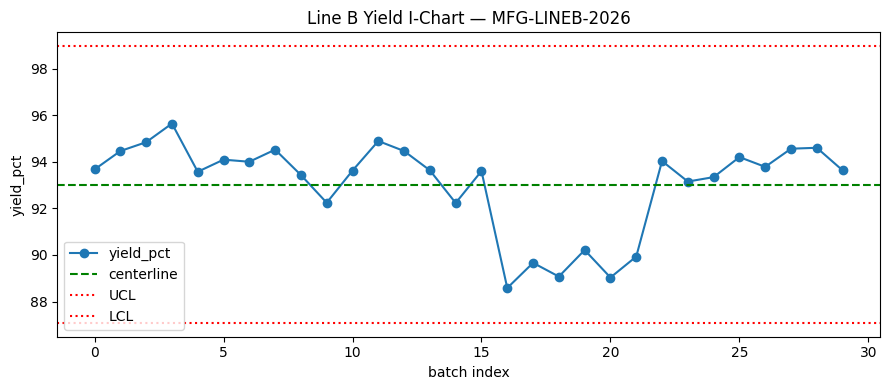

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(yield_series.index, yield_series.values, marker='o', label='yield_pct')
ax.axhline(centerline, color='green', linestyle='--', label='centerline')
ax.axhline(ucl, color='red', linestyle=':', label='UCL')
ax.axhline(lcl, color='red', linestyle=':', label='LCL')
for idx in we_results['rule1_violations']:
    ax.axvline(idx, color='orange', alpha=0.3)
ax.set_title(f'Line B Yield I-Chart — {project_id}')
ax.set_xlabel('batch index')
ax.set_ylabel('yield_pct')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

